# Laboratorio 23 - Aplicaciones: Texto e Imágenes (VQA, Captions) - Diplomado Inteligencia Artificial UC
---
**Profesora** : Bianca Del Solar Medrano
**Nombre Alumno:** Roberto Araneda

BLIP es un modelo de visión-lenguaje creado por Salesforce en 2022.
Su objetivo es entender imágenes y texto juntos, y puede hacer tareas como:

	*  Image Captioning → generar descripciones de imágenes.
	*  VQA (Visual Question Answering) → responder preguntas sobre imágenes.
	*  Image-Text Retrieval → encontrar la imagen correcta dado un texto (y al revés).

# Paso 1: Descargar e instalar Librerías

In [1]:
!pip -q install transformers timm accelerate -q

In [2]:
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image
import requests
import matplotlib.pyplot as plt

# Paso 2: Cargar modelo

Aquí cargas el modelo BLIP entrenado específicamente para VQA (Visual Question Answering).

*	BlipForQuestionAnswering es la clase de HuggingFace que implementa la arquitectura de BLIP adaptada para responder preguntas sobre imágenes.
*	.from_pretrained("Salesforce/blip-vqa-base") significa:
	*	Descarga los pesos pre-entrenados desde el repositorio de HuggingFace: "Salesforce/blip-vqa-base".
	*	Carga esos parámetros en la arquitectura del modelo.
*	Resultado: tienes un modelo listo para inferencia que, dado una imagen y una pregunta, produce una respuesta en texto.

In [3]:
# 1. Cargar modelo y procesador
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

# Paso 3: Imagen y pregunta de ejemplo

In [4]:
# 2. Imagen de ejemplo
url = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert('RGB')

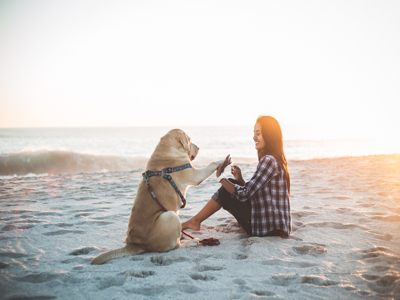

In [5]:
display(image.resize((400, 300)))

In [6]:
# 3. Pregunta
q1 = "What is this?"
q2 = "is there a girl?"

# Paso 4: Inferencia

In [7]:
# 4. Procesar entrada
inputs = processor(image, q1, return_tensors="pt")
inputs2 = processor(image, q2, return_tensors="pt")

In [8]:
# 5. Inferencia
out = model.generate(**inputs)
print("Pregunta:", q1)
print("Respuesta:", processor.decode(out[0], skip_special_tokens=True))

Pregunta: What is this?
Respuesta: dog and beach


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [9]:
out = model.generate(**inputs2)
print("Pregunta:", q2)
print("Respuesta:", processor.decode(out[0], skip_special_tokens=True))

Pregunta: is there a girl?
Respuesta: yes


Probemos otra imagen y veamos que pasa

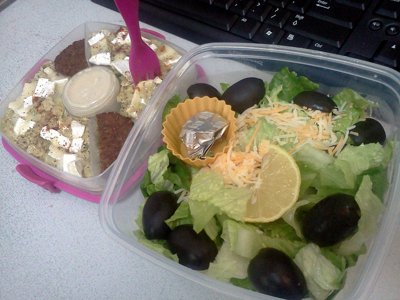

What is the black objects on the salad called?


In [10]:
img_url = 'https://storage.googleapis.com/sfr-vision-language-research/LAVIS/projects/pnp-vqa/demo.png'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
# raw_image = Image.open("./demo.png").convert("RGB")
display(raw_image.resize((400, 300)))
question = "What is the black objects on the salad called?"
print(question)

In [11]:
inputs3 = processor(raw_image, question, return_tensors="pt")

In [12]:
# 5. Inferencia
out = model.generate(**inputs3)
print("Pregunta:", question)
print("Respuesta:", processor.decode(out[0], skip_special_tokens=True))

Pregunta: What is the black objects on the salad called?
Respuesta: olives


Ahora otro ejemplo

In [13]:
img_url = 'http://images.cocodataset.org/train2017/000000505539.jpg'
raw_image2 = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

In [14]:
question_1 = 'How many giraffes are there?'
question_2 = 'Are there 2 giraffes?'

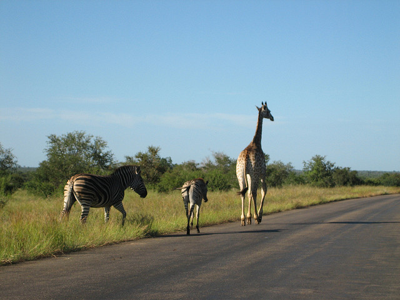

Question 1: How many giraffes are there?
Question 2: Are there 2 giraffes?


In [15]:
display(raw_image2.resize((400, 300)))
print('Question 1:', question_1)
print('Question 2:', question_2)

In [16]:
inputs4 = processor(raw_image2, question_1, return_tensors="pt")
inputs5 = processor(raw_image2, question_2, return_tensors="pt")

In [17]:
# 5. Inferencia
out = model.generate(**inputs4)
print("Pregunta:", question_1)
print("Respuesta:", processor.decode(out[0], skip_special_tokens=True))
out = model.generate(**inputs4)
print("Pregunta:", question_2)
print("Respuesta:", processor.decode(out[0], skip_special_tokens=True))

Pregunta: How many giraffes are there?
Respuesta: 1
Pregunta: Are there 2 giraffes?
Respuesta: 1


# Algunos Errores Vistos en Clases

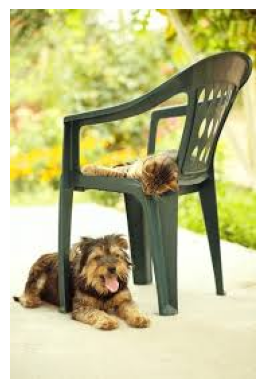

❓ Is the dog in front of the chair?
🤖 yes


In [18]:
url= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQIWnh7_YUBZYqqmLq-kbcwk8_YoWgLx-AjMQ&s"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

plt.imshow(image); plt.axis("off"); plt.show()

question = "Is the dog in front of the chair?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
print("❓", question)
print("🤖", processor.decode(out[0], skip_special_tokens=True))

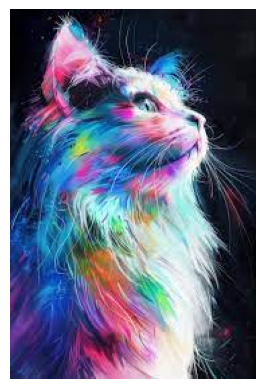

❓ What color is the cat?
🤖 multi colored


In [19]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcROR_zxr5wV_jVeKLklXXM_974a_fxEg-MVh9184W9Q2eWfn0x9HJ9nUVuy6moi-UvczDQ&usqp=CAU"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
plt.imshow(image); plt.axis("off"); plt.show()
question = "What color is the cat?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
answer = processor.decode(out[0], skip_special_tokens=True)

print("❓", question)
print("🤖", answer)


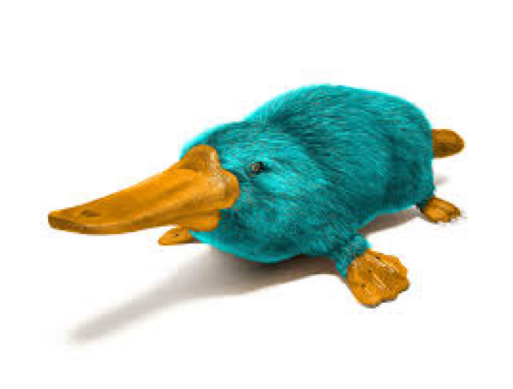

❓ What is this?
🤖 toy


In [20]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQtMdbBAjMYrhYghbDXqkW5iLuLxuUaMsRE_Q&s"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
plt.imshow(image); plt.axis("off"); plt.show()
question = "What is this?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
answer = processor.decode(out[0], skip_special_tokens=True)

print("❓", question)
print("🤖", answer)

In [23]:
url = "https://i0.wp.com/codigoespagueti.com/wp-content/uploads/2020/12/El-ornitorrinco-es-un-animal-excepcional-y-por-si-fuera-poco-su-piel-es-fluorescente-1.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
plt.imshow(image); plt.axis("off"); plt.show()
question = "What kind of animal is this?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
answer = processor.decode(out[0], skip_special_tokens=True)

print("❓", question)
print("🤖", answer)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7e4caca61d00>

In [24]:
import requests
from io import BytesIO
from PIL import Image

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

def load_image(url):
    resp = requests.get(url, headers=HEADERS, timeout=20)
    resp.raise_for_status()                      # lanza error claro si fue 403/404
    ctype = resp.headers.get("Content-Type", "")
    if "image" not in ctype:                     # te dice si llegó HTML en vez de imagen
        raise ValueError(f"La URL no devolvió una imagen (Content-Type={ctype}). "
                         f"Primeros bytes: {resp.content[:80]}")
    return Image.open(BytesIO(resp.content)).convert("RGB")

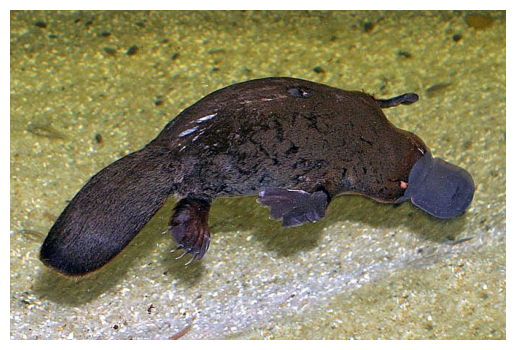

❓ What kind of animal is this?
🤖 slug


In [26]:
url = "https://upload.wikimedia.org/wikipedia/commons/f/f2/Platypus.jpg"
image = load_image(url)
plt.imshow(image); plt.axis("off"); plt.show()

question = "What kind of animal is this?"
inputs = processor(image, question, return_tensors="pt")
out = model.generate(**inputs)
print("❓", question)
print("🤖", processor.decode(out[0], skip_special_tokens=True))

# Image Captioning

El Image Captioning es la tarea de generar una descripción en lenguaje natural a partir de una imagen. La idea es que, al ver una foto, el modelo pueda producir automáticamente una frase como “A dog running on the grass”. Esta tarea es fundamental porque combina visión por computador y procesamiento de lenguaje natural, permitiendo que las máquinas traduzcan lo que ven en texto entendible para las personas.

En el caso de BLIP (Bootstrapping Language-Image Pretraining), el proceso se apoya en tres componentes principales. Primero está el Vision Encoder, basado en un Vision Transformer (ViT), que convierte la imagen en representaciones numéricas o “tokens visuales”. Luego entra el Q-Former (Query Transformer), que actúa como un puente entre visión y lenguaje, seleccionando la información visual más relevante para la tarea. Finalmente, el Language Model toma esa representación y genera la frase en lenguaje natural que describe la escena.

Cuando usamos el código en HuggingFace, la clase BlipForConditionalGeneration representa el modelo de captioning entrenado con pares imagen-texto. Su compañero, BlipProcessor, es el encargado de preparar los datos de entrada: redimensiona y normaliza la imagen, y la convierte en tensores listos para el modelo. El flujo completo consiste en pasar la imagen al processor, generar la descripción con model.generate, y finalmente decodificar la salida de nuevo en texto con processor.decode.

A pesar de su potencia, BLIP también presenta limitaciones. Muchas veces produce descripciones muy generales, como “a person” en lugar de “a woman in a red hat”. En otras ocasiones incurre en alucinaciones, inventando objetos que no están presentes en la imagen. También puede confundir atributos, por ejemplo al describir un objeto de un color distinto, o centrarse solo en lo más evidente y dejar fuera detalles importantes del contexto.

En resumen, en Image Captioning BLIP no responde a una pregunta específica como en VQA, sino que produce una frase autónoma que describe lo que hay en la imagen. Es una tarea excelente para un laboratorio porque permite observar tanto los aciertos del modelo como sus errores más característicos.

In [27]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests, matplotlib.pyplot as plt

# Modelo BLIP Caption (base)
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

def show_and_caption(url):
    # Mostrar imagen
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    plt.imshow(image); plt.axis("off"); plt.show()

    # Generar caption
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs, max_length=20)
    caption = processor.decode(out[0], skip_special_tokens=True)

    print("🤖 Caption:", caption)
    return caption

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

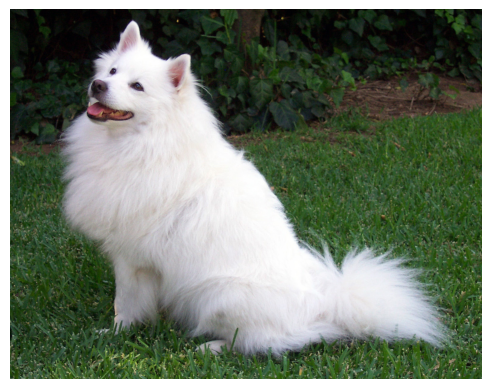

🤖 Caption: a white dog sitting in the grass


'a white dog sitting in the grass'

In [28]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
show_and_caption(url)

In [29]:
url = "https://i0.wp.com/codigoespagueti.com/wp-content/uploads/2020/12/El-ornitorrinco-es-un-animal-excepcional-y-por-si-fuera-poco-su-piel-es-fluorescente-1.jpg"
show_and_caption(url)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7e4cac0dca90>

In [30]:
def show_and_caption(url):
    image = load_image(url)              # ← en vez de Image.open(requests.get(...).raw)
    plt.imshow(image); plt.axis("off"); plt.show()

    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs, max_length=20)
    caption = processor.decode(out[0], skip_special_tokens=True)
    print("🤖 Caption:", caption)
    return caption

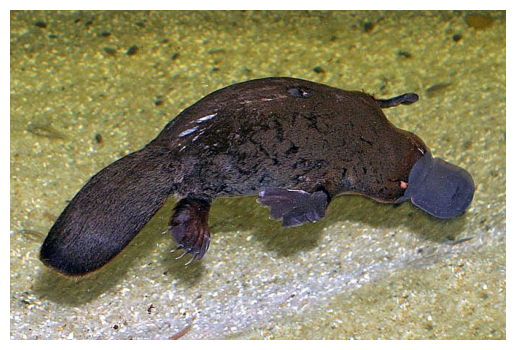

🤖 Caption: a black and white squid swimming in the ocean


'a black and white squid swimming in the ocean'

In [31]:
url = "https://upload.wikimedia.org/wikipedia/commons/f/f2/Platypus.jpg"
show_and_caption(url)

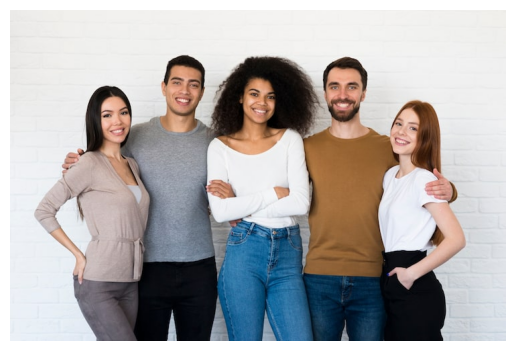

🤖 Caption: group of young people standing in front of white brick wall


'group of young people standing in front of white brick wall'

In [32]:
url = "https://img.freepik.com/foto-gratis/comunidad-jovenes-positivos-juntos_23-2148431352.jpg?semt=ais_hybrid&w=740&q=80"
show_and_caption(url)

# Actividad

1. ¿Qué es Visual Question Answering (VQA)?

In [ ]:
Respuesta = "b) Un modelo que responde preguntas sobre una imagen." # @param ["a) Un sistema que traduce texto a imágenes.","b) Un modelo que responde preguntas sobre una imagen.","c) Una red neuronal que clasifica únicamente objetos.","d) Un método para medir la calidad de captions.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

2. ¿Qué característica tiene el dataset VQAv2 para evitar sesgos en el lenguaje?

In [ ]:
Respuesta = "b) Se incluyen imágenes con preguntas similares pero respuestas distintas." # @param ["a) Todas las preguntas tienen exactamente la misma longitud.","b) Se incluyen imágenes con preguntas similares pero respuestas distintas.","c) Solo contiene preguntas binarias (sí/no).","d) Se evalúa exclusivamente con BLEU.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

3. Problemas de modelos VQA como Pythia

In [ ]:
Respuesta = "b) Tienen falta de composicionalidad y dependen de sesgos de lenguaje." # @param ["a) No pueden procesar texto de más de 3 palabras.","b) Tienen falta de composicionalidad y dependen de sesgos de lenguaje.","c) Solo funcionan con imágenes sintéticas.","d) Siempre generan captions demasiado largos.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

4. ¿Qué técnica puede generar captions más variados que Greedy Search?

In [ ]:
Respuesta = "a) Beam Search" # @param ["a) Beam Search","b) Token Embedding","c) Top-Down Attention","d) BLEU","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

5. El modelo BLIP generó el caption “a baby bird is held in a box” para la imagen de un ornitorrinco bebé.

**Pregunta:** ¿Qué podemos concluir de este error?

In [ ]:
Respuesta = "a) BLIP tiene problemas de alucinación y confunde animales poco frecuentes con categorías más comunes en su entrenamiento." # @param ["a) BLIP tiene problemas de alucinación y confunde animales poco frecuentes con categorías más comunes en su entrenamiento.","b) El modelo es incapaz de generar captions en inglés.","c) BLIP siempre describe correctamente los objetos principales de una imagen.","d) El error muestra que el modelo falla porque la imagen está en baja resolución.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

6. ¿Qué mide la métrica BLEU en el contexto de Image Captioning?

In [ ]:
Respuesta = "b) La similitud entre el caption generado y uno o varios captions de referencia." # @param ["a) La cantidad de objetos detectados en la imagen.","b) La similitud entre el caption generado y uno o varios captions de referencia.","c) La exactitud con que el modelo clasifica animales poco comunes.","d) La atención visual aplicada en el Vision Transformer.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}

7. El modelo BLIP respondió “yes” a la pregunta “Is the dog in front of the chair?”, cuando en la imagen el perro está debajo y al lado de la silla.

Pregunta: ¿Qué tipo de error se observa en este resultado?

In [ ]:
Respuesta = "b) El modelo se confunde con la relación espacial entre objetos." # @param ["a) El modelo falla en el reconocimiento de objetos (no detecta al perro).","b) El modelo se confunde con la relación espacial entre objetos.","c) El modelo no puede responder preguntas binarias.","d) El error se debe a la baja resolución de la imagen.","e) ninguna de los anteriores","Ingresa tu respuesta"] {"allow-input":true}